In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


%matplotlib inline

In [2]:
df1 = pd.read_csv('datasets/aqi_cities.csv', encoding='latin1')
df2 = pd.read_csv('datasets/deaths.csv', encoding='latin1')
df3 = pd.read_csv('datasets/vehicle.csv', encoding='latin1')
df4 = pd.read_excel('datasets/population.xlsx')

aqi = df1.copy()
health_con = df2.copy()
vehicle = df3.copy()
population = df4.copy()

In [129]:
aqi

,date,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit,note
0,19-06-2025,Uttar Pradesh,Agra,5.0,"O3,PM2.5,PM10",49.0,Good,number_of_monitoring_stations in Absolute Numb...,NaN
1,19-06-2025,Karnataka,Bagalkot,1.0,PM10,46.0,Good,number_of_monitoring_stations in Absolute Numb...,NaN
2,19-06-2025,Maharashtra,Akola,1.0,PM10,26.0,Good,number_of_monitoring_stations in Absolute Numb...,NaN
3,19-06-2025,Rajasthan,Alwar,1.0,CO,76.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
4,19-06-2025,Andhra Pradesh,Amaravati,1.0,PM10,66.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
...,...,...,...,...,...,...,...,...,...
425966,01-05-2015,Uttar Pradesh,Kanpur,NaN,PM10,175.0,Moderate,number_of_monitoring_stations in Absolute Numb...,NaN
425967,01-05-2015,Uttar Pradesh,Agra,NaN,PM10,179.0,Moderate,number_of_monitoring_stations in Absolute Numb...,NaN
425968,01-05-2015,Tamil Nadu,Chennai,NaN,CO,87.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
425969,01-05-2015,Gujarat,Ahmedabad,NaN,PM2.5,168.0,Moderate,number_of_monitoring_stations in Absolute Numb...,NaN


In [4]:
aqi['date'] = pd.to_datetime(aqi['date'])

C:\Users\mayur\AppData\Local\Temp\ipykernel_13884\469448408.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  aqi['date'] = pd.to_datetime(aqi['date'])


In [5]:
aqi.drop('note', axis=1,inplace=True)

In [6]:
aqi.isnull().sum()

date                               0
state                              0
area                               0
number_of_monitoring_stations    141
prominent_pollutants               1
aqi_value                          0
air_quality_status                 0
unit                               0
dtype: int64

In [7]:
aqi.describe()

,date,number_of_monitoring_stations,aqi_value
count,425971,425830.000000,425971.000000
mean,2022-04-26 09:53:25.105511680,1.825616,118.853737
min,2015-05-01 00:00:00,1.000000,3.000000
25%,2020-09-25 00:00:00,1.000000,61.000000
50%,2022-11-06 00:00:00,1.000000,96.000000
75%,2024-03-21 00:00:00,1.000000,153.000000
max,2025-06-19 00:00:00,40.000000,500.000000
std,NaN,3.136948,79.658891


### List the top 5 and bottom 5 areas with highest average AQI. 
### (Consider areas which contains data from : December 2024 to May 2025)

In [8]:
aqi = aqi.reset_index(drop=True)

In [9]:
aqi =aqi.set_index('date')
aqi = aqi.sort_index(ascending=True)

In [136]:
aqi

,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit
date,,,,,,,
2015-05-01,Uttar Pradesh,Varanasi,NaN,PM10,157.0,Moderate,number_of_monitoring_stations in Absolute Numb...
2015-05-01,Delhi,Delhi,NaN,O3,221.0,Poor,number_of_monitoring_stations in Absolute Numb...
2015-05-01,Haryana,Faridabad,NaN,PM10,173.0,Moderate,number_of_monitoring_stations in Absolute Numb...
2015-05-01,Telangana,Hyderabad,NaN,PM2.5,189.0,Moderate,number_of_monitoring_stations in Absolute Numb...
2015-05-01,Gujarat,Ahmedabad,NaN,PM2.5,168.0,Moderate,number_of_monitoring_stations in Absolute Numb...
...,...,...,...,...,...,...,...
2025-06-19,Karnataka,Yadgir,1.0,PM10,34.0,Good,number_of_monitoring_stations in Absolute Numb...
2025-06-19,Gujarat,Ahmedabad,6.0,"PM10,CO",62.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...
2025-06-19,Maharashtra,Navi Mumbai,5.0,"PM10,NO2,O3",36.0,Good,number_of_monitoring_stations in Absolute Numb...


In [10]:
# recent 6 months AQI
aqi_6mon = aqi.loc['2024-12-01':'2025-05-30'] # loc needs datetime format, it does not work with date format
aqi_6mon


,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit
date,,,,,,,
2024-12-01,Maharashtra,Mahad,1.0,PM10,130.0,Moderate,number_of_monitoring_stations in Absolute Numb...
2024-12-01,Maharashtra,Nashik,4.0,PM2.5,204.0,Poor,number_of_monitoring_stations in Absolute Numb...
2024-12-01,Maharashtra,Mira Bhayandar,1.0,PM2.5,257.0,Poor,number_of_monitoring_stations in Absolute Numb...
2024-12-01,Rajasthan,Ajmer,1.0,PM2.5,158.0,Moderate,number_of_monitoring_stations in Absolute Numb...
2024-12-01,Karnataka,Yadgir,1.0,PM2.5,100.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...
...,...,...,...,...,...,...,...
2025-05-30,Andhra Pradesh,Kadapa,1.0,PM2.5,65.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...
2025-05-30,Uttarakhand,Dehradun,1.0,PM10,50.0,Good,number_of_monitoring_stations in Absolute Numb...
2025-05-30,Punjab,Khanna,1.0,PM2.5,105.0,Moderate,number_of_monitoring_stations in Absolute Numb...


In [11]:
# average AQI by area
aqi_6mon_gby = aqi_6mon.groupby('area')['aqi_value'].mean().reset_index().sort_values(by='aqi_value', ascending=False)
# sort_values, sorting by a particular column always applied on a dataframe object, not series.
# therefore, reset_index() is performed to make it a dataframe object from series.

In [ ]:
# top 5 and bottom 5 areas with highest average AQI

print(f"top 5 areas with high AQI : \n {aqi_6mon_gby['area'].head(5).to_list}")
print(f"Lowest AQI Areas : \n {aqi_6mon_gby['area'].tail(5).to_list}")

top 5 areas with high AQI : <bound method IndexOpsMixin.tolist of 60        Byrnihat
81           Delhi
24     Bahadurgarh
106        Hajipur
103       Gurugram
Name: area, dtype: object>
Lowest AQI Areas : <bound method IndexOpsMixin.tolist of 61     Chamarajanagar
257         Thanjavur
200     Palkalaiperur
163          Madikeri
263       Tirunelveli
Name: area, dtype: object>


In [13]:
# average AQI by states
state_gby  =  aqi.groupby("state")['aqi_value'].mean().reset_index()
state_gby

,state,aqi_value
0,Andaman and Nicobar Islands,60.523810
1,Andhra Pradesh,81.470506
2,Arunachal Pradesh,59.861194
3,Assam,114.691221
4,Bihar,165.905256
5,Chandigarh,122.829909
6,Chhattisgarh,77.832926
7,Delhi,215.895080
8,Gujarat,118.018379
9,Haryana,151.533731


<Axes: xlabel='state', ylabel='aqi value'>

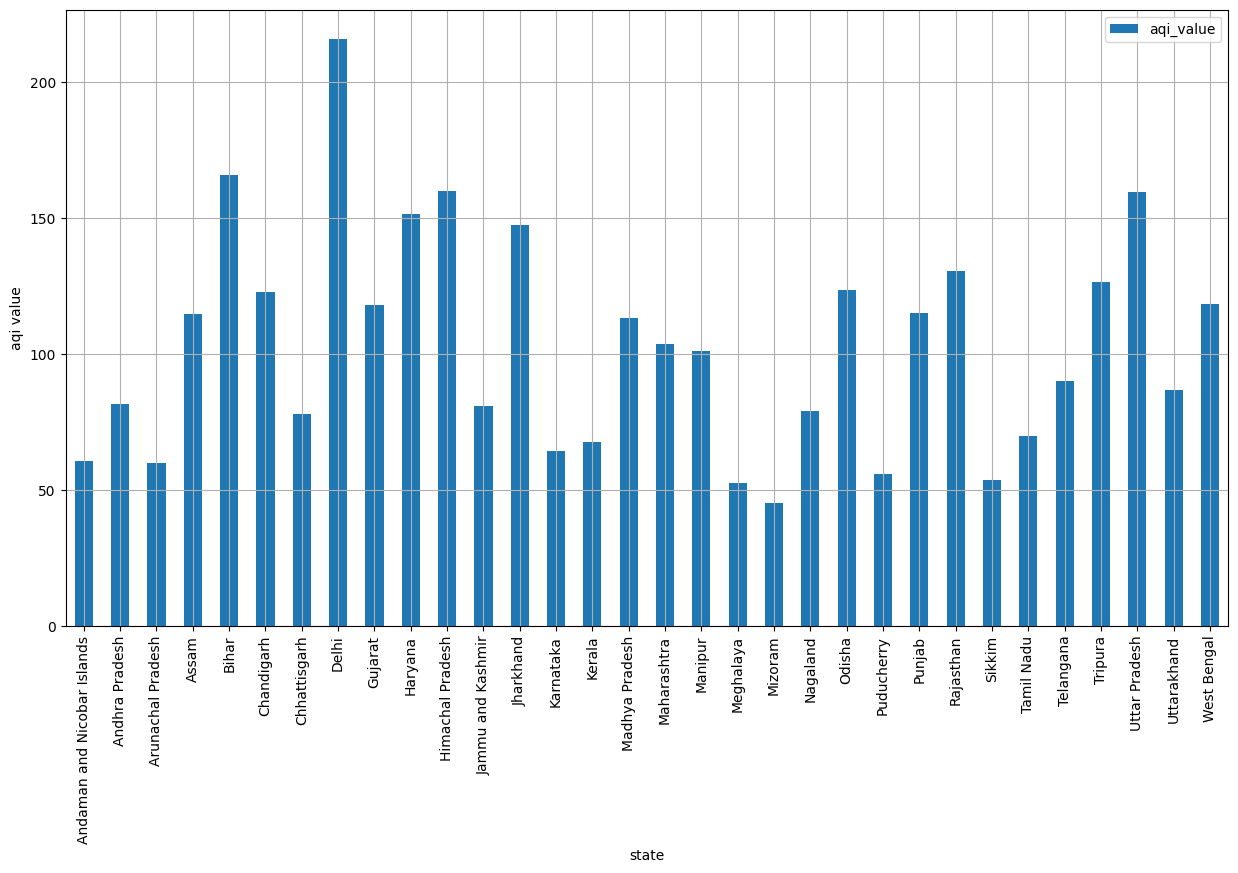

In [14]:
# plotting average AQI by states
state_gby.plot('state', 'aqi_value', figsize=(15,8), ylabel='aqi value', kind='bar', grid=True)

### Insights: Therefore, Average AQI value of Delhi is much higher as compared to that that of others.

In [15]:
aqi['prominent_pollutants'] # there are multipe polluttants in some records, handle them

date
2015-05-01             PM10
2015-05-01               O3
2015-05-01             PM10
2015-05-01            PM2.5
2015-05-01            PM2.5
                  ...      
2025-06-19             PM10
2025-06-19          PM10,CO
2025-06-19      PM10,NO2,O3
2025-06-19          PM10,O3
2025-06-19    O3,PM2.5,PM10
Name: prominent_pollutants, Length: 425971, dtype: object

In [16]:

aqi['prominent_pollutants'] = aqi['prominent_pollutants'].str.lower().str.replace(' ', '', regex=False).str.split(',') # split  into list


In [17]:
aqi = aqi.explode('prominent_pollutants') # explode separates list-like elements into separate rows.

In [18]:
aqi

,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit
date,,,,,,,
2015-05-01,Uttar Pradesh,Varanasi,NaN,pm10,157.0,Moderate,number_of_monitoring_stations in Absolute Numb...
2015-05-01,Delhi,Delhi,NaN,o3,221.0,Poor,number_of_monitoring_stations in Absolute Numb...
2015-05-01,Haryana,Faridabad,NaN,pm10,173.0,Moderate,number_of_monitoring_stations in Absolute Numb...
2015-05-01,Telangana,Hyderabad,NaN,pm2.5,189.0,Moderate,number_of_monitoring_stations in Absolute Numb...
2015-05-01,Gujarat,Ahmedabad,NaN,pm2.5,168.0,Moderate,number_of_monitoring_stations in Absolute Numb...
...,...,...,...,...,...,...,...
2025-06-19,Maharashtra,Nashik,2.0,pm10,42.0,Good,number_of_monitoring_stations in Absolute Numb...
2025-06-19,Maharashtra,Nashik,2.0,o3,42.0,Good,number_of_monitoring_stations in Absolute Numb...
2025-06-19,Uttar Pradesh,Agra,5.0,o3,49.0,Good,number_of_monitoring_stations in Absolute Numb...


### List out top 2 and bottom 2 prominent pollutants for each state of southern India. Consider data post covid: 2022 onwards

In [19]:
aqi_post_covid = aqi.loc['2022-01-01':]
aqi_post_covid.state.unique()


array(['Haryana', 'Bihar', 'Gujarat', 'Madhya Pradesh', 'Rajasthan',
       'Andhra Pradesh', 'Uttar Pradesh', 'Punjab', 'Kerala',
       'Tamil Nadu', 'Karnataka', 'Meghalaya', 'Mizoram', 'West Bengal',
       'Puducherry', 'Maharashtra', 'Assam', 'Odisha',
       'Arunachal Pradesh', 'Delhi', 'Chhattisgarh', 'Jammu and Kashmir',
       'Telangana', 'Tripura', 'Nagaland', 'Chandigarh', 'Jharkhand',
       'Himachal Pradesh', 'Sikkim', 'Manipur', 'Uttarakhand',
       'Andaman and Nicobar Islands'], dtype=object)

In [20]:
southern_states = [
    'Andhra Pradesh',
    'Kerala',
    'Tamil Nadu',
    'Karnataka',
    'Telangana',
    'Puducherry'
]
aqi_south_post_covid = aqi_post_covid[aqi_post_covid['state'].isin(southern_states)] # isin method # got all southern states data post covid (2022)

In [21]:
aqi_south_post_covid

,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit
date,,,,,,,
2022-01-01,Andhra Pradesh,Tirupati,1.0,co,39.0,Good,number_of_monitoring_stations in Absolute Numb...
2022-01-01,Kerala,Thrissur,1.0,pm10,54.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...
2022-01-01,Andhra Pradesh,Visakhapatnam,1.0,pm10,89.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...
2022-01-01,Andhra Pradesh,Rajamahendravaram,1.0,pm2.5,103.0,Moderate,number_of_monitoring_stations in Absolute Numb...
2022-01-01,Tamil Nadu,Thoothukudi,1.0,pm10,18.0,Good,number_of_monitoring_stations in Absolute Numb...
...,...,...,...,...,...,...,...
2025-06-19,Puducherry,Puducherry,1.0,o3,44.0,Good,number_of_monitoring_stations in Absolute Numb...
2025-06-19,Tamil Nadu,Pudukottai,1.0,pm10,29.0,Good,number_of_monitoring_stations in Absolute Numb...
2025-06-19,Tamil Nadu,Nagapattinam,1.0,pm10,37.0,Good,number_of_monitoring_stations in Absolute Numb...


In [22]:
prom_poll = aqi_south_post_covid.groupby(['state', 'prominent_pollutants'])['aqi_value'].mean().reset_index().sort_values(['state', 'aqi_value'] , ascending=[True, False])
prom_poll
# just like group by and order by in SQL

,state,prominent_pollutants,aqi_value
4,Andhra Pradesh,pm2.5,98.906118
3,Andhra Pradesh,pm10,73.247477
2,Andhra Pradesh,o3,62.563098
1,Andhra Pradesh,no2,54.019011
0,Andhra Pradesh,co,43.466777
5,Andhra Pradesh,so2,37.363636
11,Karnataka,pm2.5,79.457986
10,Karnataka,pm10,63.428008
6,Karnataka,co,59.216402
9,Karnataka,o3,56.964618


In [ ]:
top2_prom_poll = prom_poll.groupby('state').head(2) # top 2 prominent pollutatnts from each southern state post covid
bottom2_prom_poll = prom_poll.groupby('state').tail(2) # bottom 2 prominent pollutatnts from each state post covid
# group by again on a grouped data to apply top 2 condition (head)

print("The Top 2 Prominent Pollutants in southern States are: ")
print(top2_prom_poll)
print('\n')
print("The Bottom 2 Prominent Pollutants in southern States are: ")
print(bottom2_prom_poll)



             state prominent_pollutants   aqi_value
4   Andhra Pradesh                pm2.5   98.906118
3   Andhra Pradesh                 pm10   73.247477
11       Karnataka                pm2.5   79.457986
10       Karnataka                 pm10   63.428008
15          Kerala                  nh3   94.300000
19          Kerala                pm2.5   85.094160
24      Puducherry                pm2.5   90.252252
23      Puducherry                 pm10   51.457380
27      Tamil Nadu                  no2  100.037182
30      Tamil Nadu                pm2.5   84.854052
36       Telangana                pm2.5   91.749292
34       Telangana                   o3   85.640449


             state prominent_pollutants  aqi_value
0   Andhra Pradesh                   co  43.466777
5   Andhra Pradesh                  so2  37.363636
7        Karnataka                  nh3  44.352941
13       Karnataka                  so3  43.000000
16          Kerala                  no2  46.352564
17          Kera

Text(0, 0.5, 'average AQI')

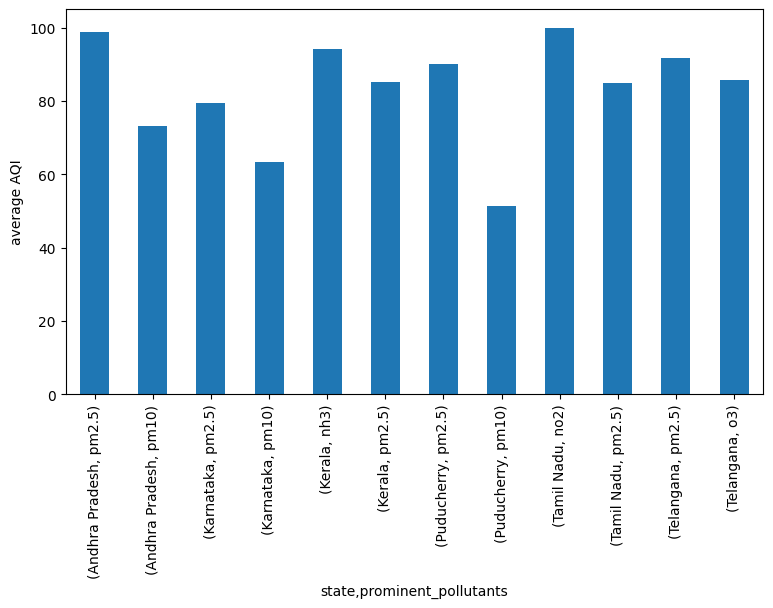

In [ ]:


top2_prom_poll.set_index(['state', 'prominent_pollutants'])['aqi_value'].plot(kind='bar', figsize=(9,5), layout='constrained').set_ylabel('average AQI')

## Does AQI improve on weekends vs weekdays in Indian metro cities (Delhi, Mumbai, Chennai, Kolkata, Bengaluru, Hyderabad, Ahmedabad, Pune)?
## (Consider data from 2024)

In [48]:
aqi_one_yr = aqi.loc['2024-01-01':'2024-12-31']
cities = ['Delhi', 'Mumbai', 'Chennai', 'Kolkata', 'Bengaluru', 'Hyderabad', 'Ahmedabad', 'Pune']
aqi_one_yr_cities = aqi_one_yr[aqi_one_yr['area'].isin(cities)].reset_index()
aqi_one_yr_cities

,date,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit
0,2024-01-01,Karnataka,Bengaluru,12.0,pm2.5,91.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...
1,2024-01-01,Karnataka,Bengaluru,12.0,pm10,91.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...
2,2024-01-01,Gujarat,Ahmedabad,9.0,pm2.5,153.0,Moderate,number_of_monitoring_stations in Absolute Numb...
3,2024-01-01,Delhi,Delhi,36.0,pm2.5,346.0,Very Poor,number_of_monitoring_stations in Absolute Numb...
4,2024-01-01,Telangana,Hyderabad,11.0,o3,108.0,Moderate,number_of_monitoring_stations in Absolute Numb...
...,...,...,...,...,...,...,...,...
5275,2024-12-31,Maharashtra,Mumbai,26.0,pm2.5,126.0,Moderate,number_of_monitoring_stations in Absolute Numb...
5276,2024-12-31,Maharashtra,Mumbai,26.0,o3,126.0,Moderate,number_of_monitoring_stations in Absolute Numb...
5277,2024-12-31,Karnataka,Bengaluru,12.0,pm10,68.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...
5278,2024-12-31,Telangana,Hyderabad,11.0,pm2.5,92.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...


In [49]:

aqi_one_yr_cities['weekdays']=aqi_one_yr_cities['date'].dt.weekday
aqi_one_yr_cities['day_name']=aqi_one_yr_cities['date'].dt.day_name()

aqi_one_yr_cities

,date,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit,weekdays,day_name
0,2024-01-01,Karnataka,Bengaluru,12.0,pm2.5,91.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...,0,Monday
1,2024-01-01,Karnataka,Bengaluru,12.0,pm10,91.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...,0,Monday
2,2024-01-01,Gujarat,Ahmedabad,9.0,pm2.5,153.0,Moderate,number_of_monitoring_stations in Absolute Numb...,0,Monday
3,2024-01-01,Delhi,Delhi,36.0,pm2.5,346.0,Very Poor,number_of_monitoring_stations in Absolute Numb...,0,Monday
4,2024-01-01,Telangana,Hyderabad,11.0,o3,108.0,Moderate,number_of_monitoring_stations in Absolute Numb...,0,Monday
...,...,...,...,...,...,...,...,...,...,...
5275,2024-12-31,Maharashtra,Mumbai,26.0,pm2.5,126.0,Moderate,number_of_monitoring_stations in Absolute Numb...,1,Tuesday
5276,2024-12-31,Maharashtra,Mumbai,26.0,o3,126.0,Moderate,number_of_monitoring_stations in Absolute Numb...,1,Tuesday
5277,2024-12-31,Karnataka,Bengaluru,12.0,pm10,68.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...,1,Tuesday
5278,2024-12-31,Telangana,Hyderabad,11.0,pm2.5,92.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...,1,Tuesday


In [57]:
weekend = ['Saturday', 'Sunday']
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday','Friday']

# aqi on weekends and weekdays in metro cities
aqi_cities = aqi_one_yr_cities.groupby(['area','day_name'])['aqi_value'].mean().reset_index()
aqi_on_weekend = aqi_cities[aqi_cities['day_name'].isin(weekend)]
aqi_on_weekdays = aqi_cities[aqi_cities['day_name'].isin(weekdays)]


In [58]:

aqi_on_weekend

,area,day_name,aqi_value
2,Ahmedabad,Saturday,106.541176
3,Ahmedabad,Sunday,109.369048
9,Bengaluru,Saturday,74.255319
10,Bengaluru,Sunday,73.526882
16,Chennai,Saturday,69.419048
17,Chennai,Sunday,72.285714
23,Delhi,Saturday,188.365591
24,Delhi,Sunday,194.521739
30,Hyderabad,Saturday,76.974359
31,Hyderabad,Sunday,78.366667


<Axes: xlabel='area,day_name'>

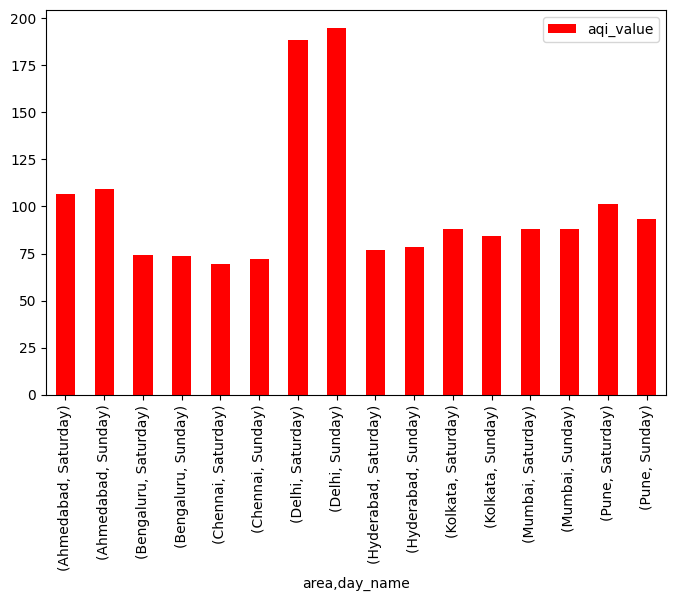

In [63]:
aqi_on_weekend.set_index(['area','day_name']).plot(y='aqi_value', kind='bar', color='red', figsize=(8,5))

In [64]:
aqi_on_weekdays

,area,day_name,aqi_value
0,Ahmedabad,Friday,111.074074
1,Ahmedabad,Monday,103.956044
4,Ahmedabad,Thursday,110.262500
5,Ahmedabad,Tuesday,104.711340
6,Ahmedabad,Wednesday,110.480519
7,Bengaluru,Friday,72.463158
8,Bengaluru,Monday,71.082474
11,Bengaluru,Thursday,72.445545
12,Bengaluru,Tuesday,73.266667
13,Bengaluru,Wednesday,75.018519


In [60]:
aqi_on_weekdays['aqi_value'].mean() - aqi_on_weekend['aqi_value'].mean() # output = np.float64(0.1069469624782613)
# AQI is slightly lower on weekends compared to weekdays, indicating a marginal improvement in air quality, though the difference is very small.

np.float64(0.1069469624782613)

<Axes: xlabel='area,day_name'>

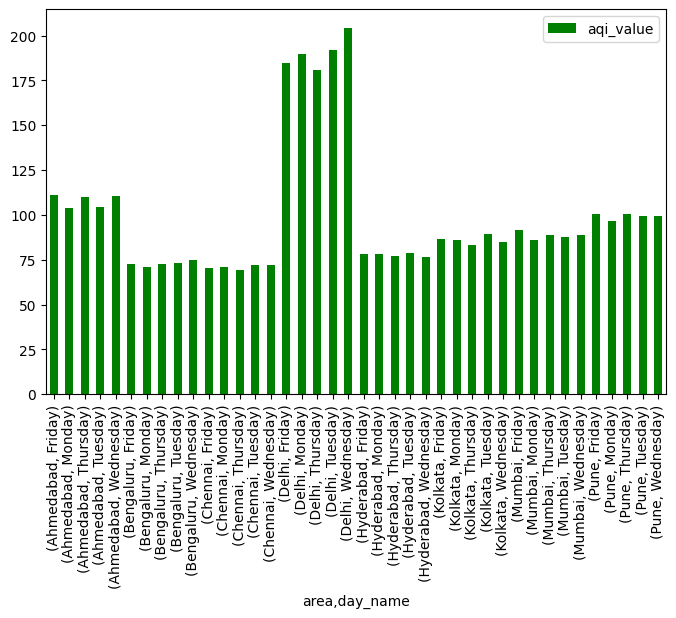

In [68]:
aqi_on_weekdays.set_index(['area','day_name']).plot(y='aqi_value', kind='bar', color='green', figsize=(8,5))

### Insights: AQI is slightly lower on weekends compared to weekdays, indicating a marginal improvement in air quality, though the difference is very small (0.1)

###  Which month show the worst air quality across Indian states in 2024?

In [84]:
aqi_one_yr = aqi_one_yr.reset_index()
aqi_one_yr['month_name']=aqi_one_yr['date'].dt.month_name()
a= aqi_one_yr.groupby(['state','month_name'])['aqi_value'].mean().reset_index().sort_values(['state','aqi_value'], ascending=[True,False])
b= a.groupby('state').head(3) # top 3 months from each state with maximum aqi
b['month_name'].mode() # january was the worst month across Indian states in 2024 with highest AQI


0    January
Name: month_name, dtype: object

### Insights : January has shown the worst Average Air Quality across Indian States in the year 2024

Text(0, 0.5, 'avg AQI')

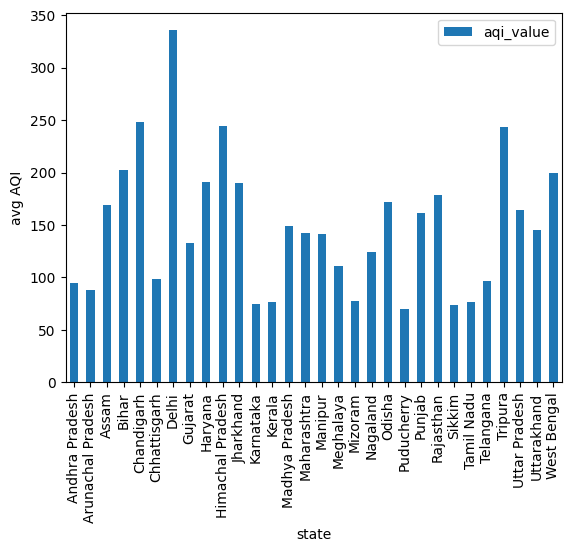

In [95]:
b.groupby('state')['aqi_value'].mean().reset_index().plot(x='state', y='aqi_value', kind='bar').set_ylabel('avg AQI') # in 2024, state vs avg aqi value

### For the city of Bengaluru, how many days fell under each air quality category (e.g., Good, Moderate, Poor, etc.) between March and May 2025?

In [96]:
aqi = aqi.reset_index()
aqi_bangalore = aqi[
    (aqi['date'] >= '2025-03-01') &
    (aqi['date'] <= '2025-05-30') &
    (aqi['area']=='Bengaluru')
]

aqi_bangalore

,date,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit
455336,2025-03-01,Karnataka,Bengaluru,10.0,pm10,67.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...
455613,2025-03-02,Karnataka,Bengaluru,11.0,pm10,74.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...
455872,2025-03-03,Karnataka,Bengaluru,10.0,pm10,74.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...
456193,2025-03-04,Karnataka,Bengaluru,13.0,pm10,100.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...
456568,2025-03-05,Karnataka,Bengaluru,13.0,pm2.5,110.0,Moderate,number_of_monitoring_stations in Absolute Numb...
...,...,...,...,...,...,...,...,...
478528,2025-05-27,Karnataka,Bengaluru,11.0,pm2.5,53.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...
478529,2025-05-27,Karnataka,Bengaluru,11.0,pm10,53.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...
478888,2025-05-28,Karnataka,Bengaluru,12.0,pm10,55.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...
479114,2025-05-29,Karnataka,Bengaluru,11.0,pm10,51.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...


In [97]:
c =aqi_bangalore.groupby('air_quality_status')['date'].count().reset_index()
c # these many days fell under each category in bengaluru between march to may in 2025

,air_quality_status,date
0,Good,8
1,Moderate,28
2,Satisfactory,124


Text(0, 0.5, 'number of days')

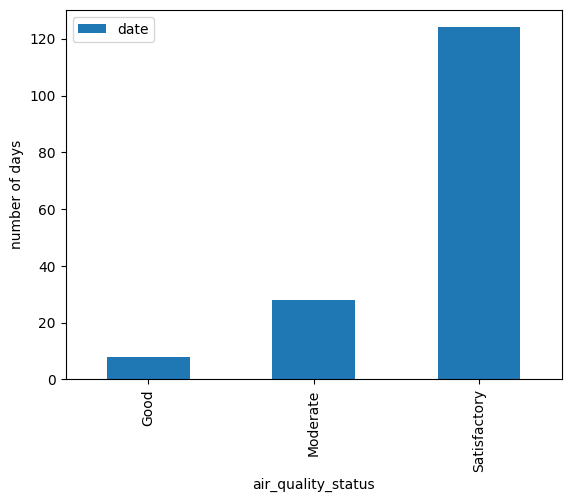

In [100]:
c.plot(x='air_quality_status', y='date', kind='bar').set_ylabel('number of days')

### List the top two most reported disease illnesses in each state over past three years (as of 2026), along with the corresponding average Air Quality Index (AQI) for that period. 

In [101]:
health_con

,year,week,outbreak_starting_date,reporting_date,state,district,disease_illness_name,status,cases,deaths,unit,note
0,2025,14,05-04-2025,05-04-2025,Assam,Biswanath,Food Poisoning,Reported,18.0,0.0,"cases in absolute number, deaths in absolute n...",NaN
1,2025,14,03-04-2025,04-04-2025,Bihar,Aurangabad,Fever with Rash,Reported,21.0,0.0,"cases in absolute number, deaths in absolute n...",NaN
2,2025,14,31-03-2025,04-04-2025,Bihar,Madhubani,Chickenpox,Reported,14.0,0.0,"cases in absolute number, deaths in absolute n...",NaN
3,2025,14,03-04-2025,04-04-2025,Gujarat,Bhavnagar,Food Poisoning,Reported,20.0,0.0,"cases in absolute number, deaths in absolute n...",NaN
4,2025,14,01-04-2025,01-04-2025,Gujarat,Vadodara,Acute Diarrheal Disease,Reported,20.0,0.0,"cases in absolute number, deaths in absolute n...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
26548,2009,25,20-06-2009,20-06-2009,Uttar Pradesh,Gorakhpur,Food Poisoning,Reported in Same Week,13.0,0.0,"cases in absolute number, deaths in absolute n...",NaN
26549,2009,25,13-06-2009,18-06-2009,Uttar Pradesh,Rae Bareli,Chickenpox,Reported in Same Week,14.0,0.0,"cases in absolute number, deaths in absolute n...",NaN
26550,2009,25,07-06-2009,NaN,Uttarakhand,Nainital,Hepatitis,Reported Late,10.0,1.0,"cases in absolute number, deaths in absolute n...",NaN
26551,2009,25,04-06-2009,NaN,Uttarakhand,Udham Singh Nagar,Enteric Fever,Reported Late,35.0,0.0,"cases in absolute number, deaths in absolute n...",NaN


In [102]:
health_con = health_con[health_con['state'].notna()] # dropping the columns with empty states, because with empty states, 
# other columns like district and reporting date were empty too. as this small deleted data without area info won't affect the results too much, so filter them out or drop them.

In [103]:
health_con = health_con[(health_con['year']>2022) & (health_con['year']<2026) & (health_con['status']!='Previous Week Follow up')] # past three years data, we only want data with
# 'reported' status

In [104]:
health_con.disease_illness_name.unique()

array(['Food Poisoning', 'Fever with Rash', 'Chickenpox',
       'Acute Diarrheal Disease', 'Hepatitis A', 'Leishmaniasis',
       'Measles', 'Typhoid', 'Mumps', 'Dengue', 'Human Rabies',
       'West Nile Fever', 'Cholera', 'Scrub Typhus', 'HMPV', 'Malaria',
       'Mpox', 'Others', 'Hepatitis A and E', 'Acute Gastroenteritis',
       'Fever', 'Meningitis', 'Jaundice', 'Acute Hepatitis A', 'Rabies',
       'Paratyphoid', 'Kannad', 'Acute Gastroentiritis', 'Chikungunya',
       'Khasi', 'Acute Hepatitis E', 'Pertussis', 'Rubella', 'Champaran',
       'Measles and Rubella', 'Hepatitis', 'Gastroenteritis',
       'Nile Fever', 'Poisoning', 'Nagar', 'Hepatitis E',
       'Crimean Congo Haemandrhagic Fever (CCHF)',
       'Japanese Encephalitis', 'Diarrhoea', 'Leptospirosis', 'Kameng',
       'Acute Gastroenteritis (Norovirus)', 'Dengue and Chikungunya',
       'Dysentery', 'Diphtheria', 'Acute Hepatitis', 'Forest Disease',
       'Enteric Fever', 'Fever with rash', 'Scrub typhus', 'Zika V

In [105]:
gby_health_con = health_con.groupby(['state','disease_illness_name'])['cases'].sum().reset_index().sort_values(by='cases', ascending=False)

In [106]:
gby_health_con # from 2023 to end of 2025

,state,disease_illness_name,cases
245,Kerala,Food Poisoning,8908.0
85,Chhattisgarh,Acute Diarrheal Disease,7818.0
309,Maharashtra,Acute Diarrheal Disease,6787.0
191,Karnataka,Acute Diarrheal Disease,6332.0
182,Jharkhand,Malaria,5731.0
...,...,...,...
209,Karnataka,Influenza,1.0
497,Uttar,Human Rabies,1.0
159,Jammu and Kashmir,HMPV,1.0
168,Jammu and Kashmir,Rabies,1.0


In [107]:
top2_diseases = (
    gby_health_con
    .sort_values(['state','cases'], ascending=[True,False])
    .groupby('state')
    .head(2)
)
top2_diseases

,state,disease_illness_name,cases
0,Andaman and Nicobar Islands,Acute Diarrheal Disease,94.0
2,Andaman and Nicobar Islands,Fever with Rash,8.0
3,Andhra Pradesh,Acute Diarrheal Disease,3167.0
5,Andhra Pradesh,Cholera,1081.0
13,Arunachal,Rabies,1.0
...,...,...,...
508,Uttar Pradesh,Food Poisoning,2218.0
522,Uttarakhand,Dengue,1092.0
520,Uttarakhand,Acute Diarrheal Disease,626.0
530,West Bengal,Acute Diarrheal Disease,3265.0


In [108]:
aqi = aqi.reset_index()

In [109]:
aqi_past_3_yr = aqi[(pd.to_datetime(aqi['date']).dt.year>2023) & (pd.to_datetime(aqi['date']).dt.year<2026)]

In [110]:
avg_aqi_statewise = aqi_past_3_yr.groupby('state')['aqi_value'].mean().reset_index().sort_values(by='aqi_value',ascending=False).rename(columns = {'aqi_value':'avg_aqi'})
avg_aqi_statewise

,state,avg_aqi
7,Delhi,192.798883
10,Himachal Pradesh,164.104563
11,Jharkhand,151.659389
5,Chandigarh,136.047561
9,Haryana,134.957305
4,Bihar,131.201592
27,Tripura,131.132159
23,Rajasthan,125.020994
20,Odisha,117.197320
30,West Bengal,113.937641


In [111]:
final_merged = top2_diseases.merge(avg_aqi_statewise, on = "state", how="inner")

In [112]:
final_merged #done 

,state,disease_illness_name,cases,avg_aqi
0,Andaman and Nicobar Islands,Acute Diarrheal Disease,94.0,60.523810
1,Andaman and Nicobar Islands,Fever with Rash,8.0,60.523810
2,Andhra Pradesh,Acute Diarrheal Disease,3167.0,74.270446
3,Andhra Pradesh,Cholera,1081.0,74.270446
4,Arunachal Pradesh,Acute Diarrheal Disease,290.0,63.355556
5,Arunachal Pradesh,Mumps,133.0,63.355556
6,Assam,Acute Diarrheal Disease,2683.0,108.601139
7,Assam,Food Poisoning,1711.0,108.601139
8,Bihar,Acute Diarrheal Disease,1295.0,131.201592
9,Bihar,Fever with Rash,825.0,131.201592


In [113]:
final_merged[['cases', 'avg_aqi']].corr()

,cases,avg_aqi
cases,1.000000,-0.007572
avg_aqi,-0.007572,1.000000


<Axes: >

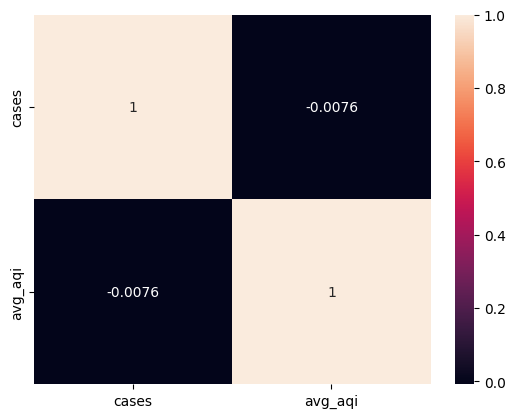

In [114]:
sns.heatmap(final_merged[['cases', 'avg_aqi']].corr(), annot=True)

### Insights: There is no Positive Correlation between number of cases and Average AQI. There is a negligible negative correlation between these two features, it can be ignored.

# List the top 5 states with high EV adoption and analyse if their average AQI is significantly better compared to states with lower EV adoption 

In [115]:
vehicle_past_3_yr = vehicle[(vehicle['year']>2022) & (vehicle['year']<2026)] # past 3 years data

In [116]:
vehicle_past_3_yr.fuel.unique()

array(['DIESEL', 'PETROL', 'ELECTRIC(BOV)', 'PETROL/ETHANOL', 'PURE EV',
       'PETROL/HYBRID', 'STRONG HYBRID EV', 'CNG ONLY', 'PETROL/CNG',
       'ETHANOL', 'DIESEL/HYBRID', 'NOT APPLICABLE', 'LPG ONLY',
       'PLUG-IN HYBRID EV', 'LNG', 'DUAL DIESEL/LNG', 'PETROL/LPG',
       'FUEL CELL HYDROGEN', 'SOLAR'], dtype=object)

In [117]:
EV = [
    'ELECTRIC(BOV)',
    'PURE EV',
    'STRONG HYBRID EV',
    'PLUG-IN HYBRID EV'
]

In [118]:
vehicle_gby = vehicle_past_3_yr.groupby(['state', 'fuel'])['value'].sum().reset_index()

In [119]:
vehicle_gby = vehicle_gby[vehicle_gby['fuel'].isin(EV)].sort_values(by='value', ascending=False).rename(columns={'value':'count_EV'})
# only EVs fuel type and thier counts
vehicle_gby

,state,fuel,count_EV
391,Uttar Pradesh,ELECTRIC(BOV),641410
249,Maharashtra,ELECTRIC(BOV),360493
192,Karnataka,ELECTRIC(BOV),293634
49,Bihar,ELECTRIC(BOV),202291
365,Tamil Nadu,ELECTRIC(BOV),199099
...,...,...,...
20,Andhra Pradesh,PLUG-IN HYBRID EV,2
217,Kerala,PLUG-IN HYBRID EV,2
226,Ladakh,STRONG HYBRID EV,2
202,Karnataka,PLUG-IN HYBRID EV,1


In [120]:
top_5_states_ev = vehicle_gby.groupby('state')['count_EV'].sum().reset_index().sort_values(by='count_EV', ascending=False).head(5)
top_5_states_ev

,state,count_EV
32,Uttar Pradesh,753501
20,Maharashtra,506242
15,Karnataka,382337
30,Tamil Nadu,265312
28,Rajasthan,228910


Text(0, 0.5, 'number of EVs')

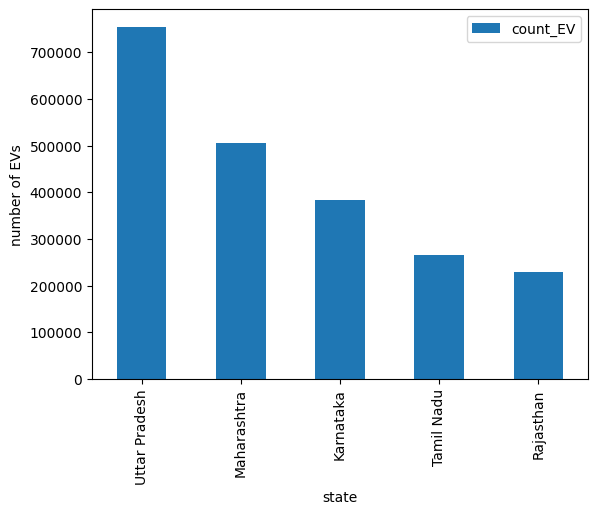

In [130]:
top_5_states_ev.plot(kind='bar', x='state', y='count_EV').set_ylabel("number of EVs")

In [121]:
vehicle_gby_3 = vehicle_past_3_yr.groupby(['state', 'fuel'])['value'].sum().reset_index()

In [122]:

vehicle_gby_3 = vehicle_gby_3[~vehicle_gby_3['fuel'].isin(EV)]# vehicle fuel type not in EV list

In [123]:
vehicle_gby_3 = vehicle_gby_3.groupby(['state','fuel'])['value'].sum().reset_index()

In [124]:
bottom_5_states = vehicle_gby_3.groupby('state')['value'].sum().reset_index().sort_values(by='value', ascending=False).head(5) # bottom 5 states with low EV usage

In [125]:
bottom_5_states

,state,value
32,Uttar Pradesh,7412382
20,Maharashtra,5707862
30,Tamil Nadu,4052860
10,Gujarat,3966326
15,Karnataka,3690457


Text(0, 0.5, 'number of EVs')

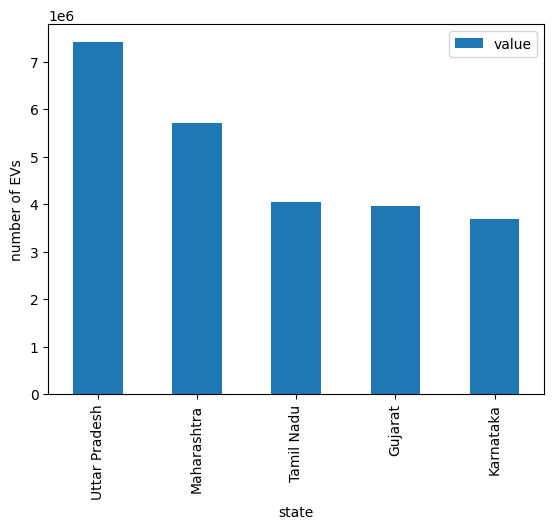

In [128]:
bottom_5_states.plot(kind='bar', x='state', y='value').set_ylabel("number of EVs")

Closure of EDA

In [4]:
population

,year,month,state,gender,value,unit,note
0,2036,October,West Bengal,Total,43964,value in Thousands,NaN
1,2036,October,West Bengal,Male,22615,value in Thousands,NaN
2,2036,October,West Bengal,Female,21349,value in Thousands,NaN
3,2036,October,Uttarakhand,Total,5506,value in Thousands,NaN
4,2036,October,Uttarakhand,Male,2922,value in Thousands,NaN
...,...,...,...,...,...,...,...
8887,2011,July,Andaman and Nicobar Islands,Male,77,value in Thousands,NaN
8888,2011,July,Andaman and Nicobar Islands,Female,67,value in Thousands,NaN
8889,2011,July,All India,Total,380145,value in Thousands,NaN
8890,2011,July,All India,Male,197066,value in Thousands,NaN


In [5]:
health_con

,year,week,outbreak_starting_date,reporting_date,state,district,disease_illness_name,status,cases,deaths,unit,note
0,2025,14,05-04-2025,05-04-2025,Assam,Biswanath,Food Poisoning,Reported,18.0,0.0,"cases in absolute number, deaths in absolute n...",NaN
1,2025,14,03-04-2025,04-04-2025,Bihar,Aurangabad,Fever with Rash,Reported,21.0,0.0,"cases in absolute number, deaths in absolute n...",NaN
2,2025,14,31-03-2025,04-04-2025,Bihar,Madhubani,Chickenpox,Reported,14.0,0.0,"cases in absolute number, deaths in absolute n...",NaN
3,2025,14,03-04-2025,04-04-2025,Gujarat,Bhavnagar,Food Poisoning,Reported,20.0,0.0,"cases in absolute number, deaths in absolute n...",NaN
4,2025,14,01-04-2025,01-04-2025,Gujarat,Vadodara,Acute Diarrheal Disease,Reported,20.0,0.0,"cases in absolute number, deaths in absolute n...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
26548,2009,25,20-06-2009,20-06-2009,Uttar Pradesh,Gorakhpur,Food Poisoning,Reported in Same Week,13.0,0.0,"cases in absolute number, deaths in absolute n...",NaN
26549,2009,25,13-06-2009,18-06-2009,Uttar Pradesh,Rae Bareli,Chickenpox,Reported in Same Week,14.0,0.0,"cases in absolute number, deaths in absolute n...",NaN
26550,2009,25,07-06-2009,NaN,Uttarakhand,Nainital,Hepatitis,Reported Late,10.0,1.0,"cases in absolute number, deaths in absolute n...",NaN
26551,2009,25,04-06-2009,NaN,Uttarakhand,Udham Singh Nagar,Enteric Fever,Reported Late,35.0,0.0,"cases in absolute number, deaths in absolute n...",NaN


In [6]:
vehicle

,year,month,state,rto,vehicle_class,fuel,value,unit,note
0,2025,April,Andaman and Nicobar Islands,All Vahan Running Office,BUS,DIESEL,2,value in Absolute Number,NaN
1,2025,April,Andaman and Nicobar Islands,All Vahan Running Office,GOODS CARRIER,DIESEL,23,value in Absolute Number,NaN
2,2025,April,Andaman and Nicobar Islands,All Vahan Running Office,GOODS CARRIER,PETROL,1,value in Absolute Number,NaN
3,2025,April,Andaman and Nicobar Islands,All Vahan Running Office,M-CYCLE/SCOOTER,ELECTRIC(BOV),1,value in Absolute Number,NaN
4,2025,April,Andaman and Nicobar Islands,All Vahan Running Office,M-CYCLE/SCOOTER,PETROL,387,value in Absolute Number,NaN
...,...,...,...,...,...,...,...,...,...
199547,2014,January,West Bengal,All Vahan Running Office,THREE WHEELER (PASSENGER),PETROL/LPG,85,value in Absolute Number,NaN
199548,2014,January,West Bengal,All Vahan Running Office,TRACTOR (COMMERCIAL),DIESEL,1156,value in Absolute Number,NaN
199549,2014,January,West Bengal,All Vahan Running Office,TRACTOR (COMMERCIAL),PETROL,5,value in Absolute Number,NaN
199550,2014,January,West Bengal,All Vahan Running Office,TRAILER (COMMERCIAL),NOT APPLICABLE,84,value in Absolute Number,NaN


In [7]:
aqi

,date,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit,note
0,19-06-2025,Uttar Pradesh,Agra,5.0,"O3,PM2.5,PM10",49.0,Good,number_of_monitoring_stations in Absolute Numb...,NaN
1,19-06-2025,Karnataka,Bagalkot,1.0,PM10,46.0,Good,number_of_monitoring_stations in Absolute Numb...,NaN
2,19-06-2025,Maharashtra,Akola,1.0,PM10,26.0,Good,number_of_monitoring_stations in Absolute Numb...,NaN
3,19-06-2025,Rajasthan,Alwar,1.0,CO,76.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
4,19-06-2025,Andhra Pradesh,Amaravati,1.0,PM10,66.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
...,...,...,...,...,...,...,...,...,...
425966,01-05-2015,Uttar Pradesh,Kanpur,NaN,PM10,175.0,Moderate,number_of_monitoring_stations in Absolute Numb...,NaN
425967,01-05-2015,Uttar Pradesh,Agra,NaN,PM10,179.0,Moderate,number_of_monitoring_stations in Absolute Numb...,NaN
425968,01-05-2015,Tamil Nadu,Chennai,NaN,CO,87.0,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
425969,01-05-2015,Gujarat,Ahmedabad,NaN,PM2.5,168.0,Moderate,number_of_monitoring_stations in Absolute Numb...,NaN


In [4]:
population_df = population.drop(columns=['unit', 'note'])[(population['year']<2027) & (population['gender']!='Total')]
population_df

,year,month,state,gender,value
3421,2026,October,West Bengal,Male,19841
3422,2026,October,West Bengal,Female,18730
3424,2026,October,Uttarakhand,Male,2404
3425,2026,October,Uttarakhand,Female,2125
3427,2026,October,Uttar Pradesh,Male,31604
...,...,...,...,...,...
8885,2011,July,Andhra Pradesh,Female,7322
8887,2011,July,Andaman and Nicobar Islands,Male,77
8888,2011,July,Andaman and Nicobar Islands,Female,67
8890,2011,July,All India,Male,197066


In [3]:
health_con['reporting_month'] = pd.to_datetime(health_con['reporting_date'], format="%d-%m-%Y").dt.month_name()

In [4]:
health_con_df = health_con.drop(columns=['week', 'outbreak_starting_date', 'district','status', 'unit', 'note' ])

In [5]:
health_con_df.head(2)

,year,reporting_date,state,disease_illness_name,cases,deaths,reporting_month
0,2025,05-04-2025,Assam,Food Poisoning,18.0,0.0,April
1,2025,04-04-2025,Bihar,Fever with Rash,21.0,0.0,April


In [55]:
vehicle_df= vehicle.drop(columns=['rto','unit','note'])

In [58]:
aqi_df = aqi.drop(columns=['unit', 'note'])

In [60]:
aqi_df['month'] = pd.to_datetime(aqi_df['date']).dt.year.astype(int)
aqi_df['year'] = pd.to_datetime(aqi_df['date']).dt.month_name()

C:\Users\mayur\AppData\Local\Temp\ipykernel_4592\23918555.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  aqi_df['month'] = pd.to_datetime(aqi_df['date']).dt.year.astype(int)
C:\Users\mayur\AppData\Local\Temp\ipykernel_4592\23918555.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  aqi_df['year'] = pd.to_datetime(aqi_df['date']).dt.month_name()


In [67]:
aqi_df = aqi_df.groupby(['month', 'year', 'state', 'area'])[['aqi_value', 'number_of_monitoring_stations']].mean().reset_index()

In [69]:
aqi_df['number_of_monitoring_stations']=aqi_df['number_of_monitoring_stations'].astype(int)

,month,year,state,area,aqi_value,number_of_monitoring_stations
0,2015,August,Delhi,Delhi,147.100000,4
1,2015,August,Gujarat,Ahmedabad,71.263158,1
2,2015,August,Haryana,Faridabad,100.233333,1
3,2015,August,Karnataka,Bengaluru,61.758621,2
4,2015,August,Maharashtra,Chandrapur,85.090909,1
...,...,...,...,...,...,...
16162,2025,May,West Bengal,Durgapur,89.483871,1
16163,2025,May,West Bengal,Haldia,46.064516,1
16164,2025,May,West Bengal,Howrah,73.000000,4
16165,2025,May,West Bengal,Kolkata,56.032258,5


In [75]:
aqi_df.to_csv('aqi.csv')

In [5]:
population_df.to_csv('population.csv')

In [77]:
vehicle_df.to_csv('vehicle.csv')

In [78]:
health_con.to_csv('health.csv')